# Univariate Cox Regression (R)

Runs one **`coxph`** model per gene to identify prognostic immune genes.

- Beta > 0 → HR > 1 → **danger** gene (higher expression = higher relapse risk)
- Beta < 0 → HR < 1 → **protective** gene

**Libraries:** `survival`, `ggplot2`, `dplyr`

In [1]:
# Uncomment to install required packages
# install.packages(c('survival', 'ggplot2', 'dplyr'))

In [2]:
suppressPackageStartupMessages({
  library(survival)
  library(ggplot2)
  library(dplyr)
})

DATA_DIR <- '../../datasets/rds_files'
VIS_DIR  <- '../../visuals'
dir.create(VIS_DIR, showWarnings = FALSE, recursive = TRUE)
message('Packages loaded successfully.')

Packages loaded successfully.



## Preparing Data

In [3]:
train_data <- read.csv(file.path(DATA_DIR, 'clinical_metadata_train.rds'),
                       stringsAsFactors = FALSE)
train_data <- train_data[complete.cases(
  train_data[c('relapse_free_time', 'relapse_free_event')]), ]
train_data$relapse_free_event <- as.integer(train_data$relapse_free_event)

gene_cols <- setdiff(names(train_data),
                     c('sample_name', 'relapse_free_time', 'relapse_free_event'))
cat(sprintf('Training samples: %d | Genes to test: %d\n',
            nrow(train_data), length(gene_cols)))
head(train_data[, 1:6])

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
"line 2 appears to contain embedded nulls"
Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
"line 3 appears to contain embedded nulls"
Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
"line 4 appears to contain embedded nulls"
Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
"line 5 appears to contain embedded nulls"


Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
"EOF within quoted string"
Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
"embedded nul(s) found in input"


ERROR: Error in `[.data.frame`(train_data, c("relapse_free_time", "relapse_free_event")): undefined columns selected


## Univariate Cox Regression Loop

For each immune DEG, fit a separate Cox model:
$$\text{Hazard}(t) = h_0(t) \cdot \exp(\beta \cdot \text{gene\_expression})$$

The model estimates β by comparing, at each event time, the expression of patients who relapsed vs those still at risk.

In [ ]:
run_univariate_cox <- function(data, genes,
                               time_col  = 'relapse_free_time',
                               event_col = 'relapse_free_event') {
  total   <- length(genes)
  results <- vector('list', total)

  for (i in seq_along(genes)) {
    gene <- genes[i]
    if (i %% 20 == 0 || i == total)
      cat(sprintf('  Processed %d/%d genes...\n', i, total))

    results[[i]] <- tryCatch({
      sub <- data[complete.cases(data[, c(time_col, event_col, gene)]),
                  c(time_col, event_col, gene)]
      fit <- coxph(as.formula(
        sprintf('Surv(%s, %s) ~ `%s`', time_col, event_col, gene)),
        data = sub)
      s <- summary(fit)
      data.frame(
        gene        = gene,
        beta        = round(s$coefficients[1, 'coef'],        4),
        HR          = round(s$conf.int[1,   'exp(coef)'],     4),
        HR_lower_95 = round(s$conf.int[1,   'lower .95'],     4),
        HR_upper_95 = round(s$conf.int[1,   'upper .95'],     4),
        p_value     = round(s$coefficients[1, 'Pr(>|z|)'],    4),
        stringsAsFactors = FALSE
      )
    }, error = function(e) {
      message(sprintf('  Skipped %s: %s', gene, conditionMessage(e)))
      NULL
    })
  }

  do.call(rbind, Filter(Negate(is.null), results))
}

In [ ]:
cat('Running univariate Cox regression...\n')
all_results <- run_univariate_cox(train_data, gene_cols)
all_results  <- all_results[order(all_results$p_value), ]

cat(sprintf('\nAll results (sorted by p-value): %d genes\n', nrow(all_results)))
all_results

Running univariate Cox regression...
  Processed 20/263 genes...
  Processed 40/263 genes...
  Processed 60/263 genes...
  Processed 80/263 genes...
  Processed 100/263 genes...
  Processed 120/263 genes...
  Processed 140/263 genes...
  Processed 160/263 genes...
  Processed 180/263 genes...
  Processed 200/263 genes...
  Processed 220/263 genes...
  Processed 240/263 genes...
  Processed 260/263 genes...
  Processed 263/263 genes...

All results (sorted by p-value): 263 genes


,gene,beta,HR,HR_lower_95,HR_upper_95,p_value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
87,FBXL5,-0.7746,0.4609,0.3313,0.6412,0.0000
79,EVL,-0.4396,0.6443,0.5187,0.8002,0.0001
187,POLR3GL,-0.6891,0.5020,0.3484,0.7235,0.0002
38,CDC20,0.4483,1.5657,1.2309,1.9916,0.0003
137,KLHL5,-0.9318,0.3938,0.2293,0.6765,0.0007
17,BLNK,-0.3943,0.6742,0.5352,0.8492,0.0008
99,GATA3,-0.2528,0.7766,0.6697,0.9006,0.0008
202,RARRES3,-0.3255,0.7222,0.5930,0.8794,0.0012
230,SOX4,1.1480,3.1519,1.5757,6.3047,0.0012


## Filter Significant Genes (p < 0.05)

In [ ]:
sig_genes_df <- all_results[all_results$p_value < 0.05, ]
sig_genes_df$role <- ifelse(sig_genes_df$HR > 1, 'danger', 'protective')

cat(strrep('=', 55), '\n')
cat(sprintf('Total genes tested:           %d\n', nrow(all_results)))
cat(sprintf('Significant genes (p < 0.05): %d\n', nrow(sig_genes_df)))
cat(strrep('=', 55), '\n\n')

sig_genes_df

Total genes tested:           263
Significant genes (p < 0.05): 55



,gene,beta,HR,HR_lower_95,HR_upper_95,p_value,role
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
87,FBXL5,-0.7746,0.4609,0.3313,0.6412,0.0000,protective
79,EVL,-0.4396,0.6443,0.5187,0.8002,0.0001,protective
187,POLR3GL,-0.6891,0.5020,0.3484,0.7235,0.0002,protective
38,CDC20,0.4483,1.5657,1.2309,1.9916,0.0003,danger
137,KLHL5,-0.9318,0.3938,0.2293,0.6765,0.0007,protective
17,BLNK,-0.3943,0.6742,0.5352,0.8492,0.0008,protective
99,GATA3,-0.2528,0.7766,0.6697,0.9006,0.0008,protective
202,RARRES3,-0.3255,0.7222,0.5930,0.8794,0.0012,protective
230,SOX4,1.1480,3.1519,1.5757,6.3047,0.0012,danger


In [ ]:
danger_genes     <- sig_genes_df$gene[sig_genes_df$role == 'danger']
protective_genes <- sig_genes_df$gene[sig_genes_df$role == 'protective']

cat('Danger genes (HR > 1):\n', paste(danger_genes, collapse = ', '), '\n')
cat('Protective genes (HR < 1):\n', paste(protective_genes, collapse = ', '), '\n')

Danger genes (HR > 1):
 CDC20, SOX4, UBE2S, SOX11, HEBP2, S100P, SFRP1, BIRC5, ARF1, UBE2E3, UBE2C, SOD2, SPHK1, MDK, CEBPD, TF, ALDOC, S100B 
Protective genes (HR < 1):
 FBXL5, EVL, POLR3GL, KLHL5, BLNK, GATA3, RARRES3, HSPA2, ERAP1, DEFB132, COLEC12, MICB, EIF4E3, COL1A2, GNS, PREX1, JAM2, FLNB, FBN1, FBXL16, CFB, C6orf120, TRIM45, GPAM, CXCL14, MTHFD1, CEBPA, VAV3, STAT5A, ACO1, DCTN6, MYB, PRLR, CXCL12, FOS, CLU, DENND1B 


## Validate Against Paper Signature

From Tian et al.: danger = TSLP, BIRC5, S100B, MDK, S100P; protective = RARRES3, BLNK, ACO1

In [ ]:
PAPER_GENES <- c('TSLP', 'BIRC5', 'S100B', 'MDK', 'S100P', 'RARRES3', 'BLNK', 'ACO1')
sig_genes_results <- all_results[all_results$gene %in% PAPER_GENES, ]
sig_genes_results

found   <- intersect(sig_genes_df$gene, PAPER_GENES)
missing <- setdiff(PAPER_GENES, sig_genes_df$gene)
cat(sprintf('\nPaper signature overlap: %d/%d\n', length(found), length(PAPER_GENES)))
cat('Found:  ', paste(found,   collapse = ', '), '\n')
cat('Missing:', paste(missing, collapse = ', '), '\n')

,gene,beta,HR,HR_lower_95,HR_upper_95,p_value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
17,BLNK,-0.3943,0.6742,0.5352,0.8492,0.0008
202,RARRES3,-0.3255,0.7222,0.5930,0.8794,0.0012
214,S100P,0.2078,1.2310,1.0687,1.4180,0.0040
16,BIRC5,0.4200,1.5220,1.0979,2.1100,0.0117
152,MDK,0.2716,1.3120,1.0335,1.6656,0.0257
1,ACO1,-1.0536,0.3487,0.1327,0.9162,0.0326
213,S100B,0.3396,1.4044,1.0079,1.9569,0.0448
244,TSLP,0.9445,2.5717,0.9279,7.1275,0.0694



Paper signature overlap: 7/8
Found:   BLNK, RARRES3, S100P, BIRC5, MDK, ACO1, S100B 
Missing: TSLP 


## Forest Plot (Figure 2B equivalent)

In [ ]:
plot_forest <- function(df, title = 'Univariate Cox: Hazard Ratios (p < 0.05)') {
  df        <- df[order(df$HR), ]
  df$gene   <- factor(df$gene, levels = df$gene)
  pal       <- c('danger' = '#E64B35', 'protective' = '#8491B4')

  ggplot(df, aes(x = HR, y = gene, colour = role)) +
    geom_vline(xintercept = 1, linetype = 'dashed',
               colour = 'black', alpha = 0.6) +
    geom_errorbarh(aes(xmin = HR_lower_95, xmax = HR_upper_95),
                   height = 0.35, linewidth = 1.1) +
    geom_point(size = 3) +
    geom_text(aes(x = HR_upper_95,
                  label = sprintf('p=%.3f', p_value)),
              hjust = -0.1, size = 2.7, colour = 'grey45') +
    scale_colour_manual(values = pal, name = '',
      labels = c('danger'     = 'Danger gene (HR > 1)',
                 'protective' = 'Protective gene (HR < 1)')) +
    labs(title = title, x = 'Hazard Ratio (95% CI)', y = NULL) +
    theme_bw(base_size = 10) +
    theme(plot.title      = element_text(face = 'bold'),
          legend.position = 'bottom')
}

Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.
`height` was translated to `width`.


Saved: forest_plot.png


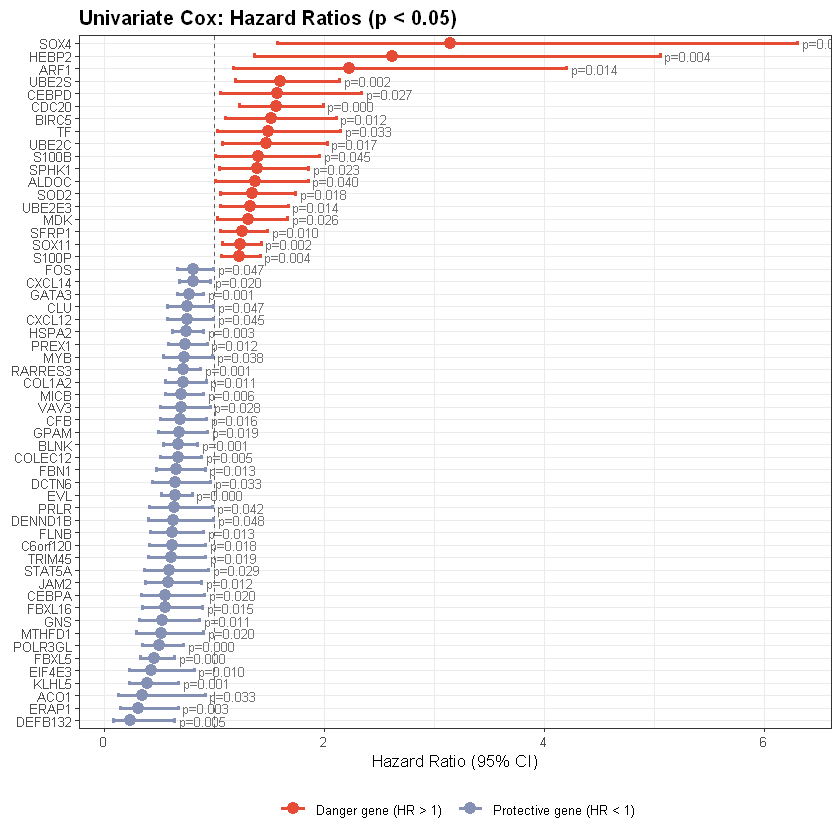

In [ ]:
p_forest <- plot_forest(sig_genes_df)
p_forest

ggsave(file.path(VIS_DIR, 'forest_plot.png'), p_forest, dpi = 150,
       width = 9, height = max(4, nrow(sig_genes_df) * 0.30))
cat('Saved: forest_plot.png\n')

## Save Results

In [ ]:
write.csv(all_results,  file.path(DATA_DIR, 'univariate_cox_all_genes_train.csv'), row.names = FALSE)
write.csv(sig_genes_df, file.path(DATA_DIR, 'univariate_cox_sig_train.csv'),       row.names = FALSE)

cat('Saved files:\n')
cat('  univariate_cox_all_genes_train.csv — full results for all genes\n')
cat('  univariate_cox_sig_train.csv       — significant genes only (p < 0.05)\n')
cat('\n--- Next steps ---\n')
cat('  Step 1: Feed sig genes into penalized_cox_r.ipynb (LASSO / Elastic Net)\n')
cat('  Step 2: Run multivariate_cox_r.ipynb with penalised genes + clinical vars\n')

Saved files:
  univariate_cox_all_genes_train.csv — full results for all genes
  univariate_cox_sig_train.csv       — significant genes only (p < 0.05)

--- Next steps ---
  Step 1: Feed sig genes into penalized_cox_r.ipynb (LASSO / Elastic Net)
  Step 2: Run multivariate_cox_r.ipynb with penalised genes + clinical vars
